In [8]:
pip install sentence_transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 174.7 kB/s  0:00:39m0:00:0100:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 177.6 kB/s  0:00:16 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 309.5 kB/s  0:05:21m0:00:0100:08
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [sentence_transformers]ence_transformers]
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 612.9/612.9 kB 799.2 kB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 346.4 kB/s  0:00:09 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [datasets]4/5 [datasets]ce-hub]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import polars as pl
import numpy as np
from datasets import load_dataset

In [5]:
ds = load_dataset("Jsevisal/go_emotions_wheel")

In [6]:
df_train = pl.from_dicts(ds['train'][:])
df_test = pl.from_dicts(ds['test'][:])
df_validation = pl.from_dicts(ds['validation'][:])

In [7]:
df_train = df_train.filter(
    ~(
        pl.col("labels").list.contains(1) |
        pl.col("labels").list.contains(5) |
        pl.col("labels").list.contains(6)
    )
)

In [8]:
df_test = df_test.filter(
    ~(
        pl.col("labels").list.contains(1) |
        pl.col("labels").list.contains(5) |
        pl.col("labels").list.contains(6)
    )
)

In [9]:
df_validation = df_validation.filter(
    ~(
        pl.col("labels").list.contains(1) |
        pl.col("labels").list.contains(5) |
        pl.col("labels").list.contains(6)
    )
)

In [10]:
from sentence_transformers import SentenceTransformer


In [11]:
model_st = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [12]:
X_train = model_st.encode(df_train['text'].to_list(), batch_size=64, show_progress_bar=True, normalize_embeddings=True)
X_test  = model_st.encode(df_test['text'].to_list(),  batch_size=64, show_progress_bar=True, normalize_embeddings=True)

Batches:   0%|          | 0/390 [00:00<?, ?it/s]

Batches:   0%|          | 0/49 [00:00<?, ?it/s]

In [13]:
X_val = model_st.encode(df_validation['text'].to_list(),  batch_size=64, show_progress_bar=True, normalize_embeddings=True)

Batches:   0%|          | 0/49 [00:00<?, ?it/s]

In [14]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier

In [15]:
y_train_raw = df_train['labels'].to_list()
y_test_raw = df_test['labels'].to_list()
y_val_raw = df_validation['labels'].to_list()

all_labels_combined = y_train_raw + y_test_raw
all_unique_label_ids = sorted(list(set(item for sublist in all_labels_combined for item in sublist)))

In [16]:
mlb = MultiLabelBinarizer(classes=all_unique_label_ids)
mlb.fit(all_labels_combined)

MultiLabelBinarizer(classes=[0, 2, 3, 4, 7, 8])

In [17]:
y_train = mlb.transform(y_train_raw)
y_test = mlb.transform(y_test_raw)

In [18]:
y_val = mlb.transform(y_val_raw)

In [19]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [20]:
model = OneVsRestClassifier(
    LogisticRegression(C=1.0, class_weight='balanced', solver='lbfgs', max_iter=500)
)

In [21]:
model.fit(X_train, y_train)

OneVsRestClassifier(estimator=LogisticRegression(class_weight='balanced',
                                                 max_iter=500))

In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import hamming_loss, jaccard_score

print("Hamming Loss:", hamming_loss(y_test, y_pred))  # menor es mejor
print("Jaccard (macro):", jaccard_score(y_test, y_pred, average='macro'))

Hamming Loss: 0.18152661962796665
Jaccard (macro): 0.35998962019130415


In [24]:
label_dict = {
  0: 'joy',
  2: 'fear',
  3: 'surprise',
  4: 'sadness',
  7: 'anger',
  8: 'disgust'
}

In [25]:
import pandas as pd
label_counts = pd.DataFrame(y_train.sum(axis=0), index=[label_dict[c] for c in mlb.classes_], columns=['count'])
print(label_counts.sort_values('count', ascending=False))

          count
joy       12518
anger      5153
surprise   4856
sadness    3005
disgust     746
fear        679


In [26]:
y_pred_proba = model.predict_proba(X_test)   # list of arrays, one per label
thresholds = [0.3, 0.25, 0.4, 0.35, 0.2, 0.15]   # example – order by label_dict

# Initialize y_pred_bin with the same shape as y_pred_proba (num_samples, num_labels)
y_pred_bin = np.zeros_like(y_pred_proba)
for i in range(len(thresholds)):
    # Apply the threshold to the i-th column (label) of y_pred_proba
    y_pred_bin[:, i] = (y_pred_proba[:, i] >= thresholds[i]).astype(int)

In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'estimator__C': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
    'estimator__penalty': ['l2'],           # l1 can work but needs liblinear solver
    'estimator__class_weight': ['balanced', None],
    'estimator__max_iter': [1000],
}

# or even try solver='saga' + elasticnet + l1_ratio grid if you want to experiment

In [28]:
model_st = SentenceTransformer('BAAI/bge-small-en-v1.5')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [29]:
X_train = model_st.encode(df_train['text'].to_list(), batch_size=64, show_progress_bar=True, normalize_embeddings=True)
X_test  = model_st.encode(df_test['text'].to_list(),  batch_size=64, show_progress_bar=True, normalize_embeddings=True)

Batches:   0%|          | 0/390 [00:00<?, ?it/s]

Batches:   0%|          | 0/49 [00:00<?, ?it/s]

In [30]:
model = OneVsRestClassifier(
    LogisticRegression(C=1.0, class_weight='balanced', solver='lbfgs', max_iter=500)
)

In [31]:
model.fit(X_train, y_train)

OneVsRestClassifier(estimator=LogisticRegression(class_weight='balanced',
                                                 max_iter=500))

In [32]:
y_pred = model.predict(X_test)

In [33]:
from sklearn.metrics import hamming_loss, jaccard_score

print("Hamming Loss:", hamming_loss(y_test, y_pred))  # menor es mejor
print("Jaccard (macro):", jaccard_score(y_test, y_pred, average='macro'))

Hamming Loss: 0.1536241180243746
Jaccard (macro): 0.4062495977354


In [34]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=[label_dict[c] for c in mlb.classes_], zero_division=0))

              precision    recall  f1-score   support

         joy       0.88      0.86      0.87      1508
        fear       0.22      0.89      0.36        92
    surprise       0.50      0.77      0.61       609
     sadness       0.38      0.82      0.52       354
       anger       0.53      0.83      0.65       676
     disgust       0.19      0.83      0.31       119

   micro avg       0.55      0.83      0.66      3358
   macro avg       0.45      0.83      0.55      3358
weighted avg       0.65      0.83      0.71      3358
 samples avg       0.65      0.84      0.70      3358



In [36]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'estimator__C': [0.05, 0.1, 0.3, 0.5, 1.0, 3.0, 10.0],
    'estimator__class_weight': ['balanced', None],
    'estimator__solver': ['lbfgs', 'saga'],  # saga allows elasticnet if you want
    'estimator__max_iter': [1000],
}

grid = GridSearchCV(
    model, param_grid, cv=3, scoring='f1_macro', n_jobs=-1
)
grid.fit(X_train, y_train)
print(grid.best_params_)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max

{'estimator__C': 10.0, 'estimator__class_weight': None, 'estimator__max_iter': 1000, 'estimator__solver': 'lbfgs'}


In [37]:
import optuna

def objective(trial):
    C = trial.suggest_float('C', 0.01, 10.0, log=True)
    class_weight = trial.suggest_categorical('class_weight', ['balanced', None])
    solver = trial.suggest_categorical('solver', ['lbfgs', 'saga'])

    model = OneVsRestClassifier(LogisticRegression(C=C, class_weight=class_weight, solver=solver, max_iter=1000))
    model.fit(X_train, y_train)

    y_pred_val = model.predict(X_val)
    score = jaccard_score(y_val, y_pred_val, average='macro')  # O f1_score(average='macro')
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)  # Ajusta trials
print(study.best_params)

[I 2026-03-08 15:13:38,346] A new study created in memory with name: no-name-5f370987-74c8-47e5-9545-45c7dd3bf6ff
[I 2026-03-08 15:13:38,760] Trial 0 finished with value: 0.03289473684210526 and parameters: {'C': 0.01683452024726753, 'class_weight': None, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.03289473684210526.
[I 2026-03-08 15:13:43,862] Trial 1 finished with value: 0.08487694886493297 and parameters: {'C': 1.6091463145438507, 'class_weight': None, 'solver': 'saga'}. Best is trial 1 with value: 0.08487694886493297.
[I 2026-03-08 15:13:44,226] Trial 2 finished with value: 0.2054374964769147 and parameters: {'C': 0.010748193516807327, 'class_weight': 'balanced', 'solver': 'lbfgs'}. Best is trial 2 with value: 0.2054374964769147.
[I 2026-03-08 15:13:48,600] Trial 3 finished with value: 0.03258145363408521 and parameters: {'C': 0.01634811331465934, 'class_weight': None, 'solver': 'saga'}. Best is trial 2 with value: 0.2054374964769147.
[I 2026-03-08 15:13:49,470] Trial 4 finis

{'C': 0.01009360681831114, 'class_weight': 'balanced', 'solver': 'lbfgs'}


In [38]:
from sklearn.metrics import f1_score
import numpy as np

def find_best_thresholds(y_true, y_proba, num_labels):
    best_thresholds = []
    for i in range(num_labels):
        thresholds = np.arange(0.1, 0.9, 0.05)
        best_score = 0
        best_th = 0.5
        for th in thresholds:
            y_pred_i = (y_proba[:, i] >= th).astype(int)
            score = f1_score(y_true[:, i], y_pred_i)
            if score > best_score:
                best_score = score
                best_th = th
        best_thresholds.append(best_th)
    return best_thresholds

# Después de fit
y_pred_proba_val = model.predict_proba(X_val)
thresholds = find_best_thresholds(y_val, y_pred_proba_val, y_val.shape[1])
print(thresholds)  # Usa estos en test

[np.float64(0.1), np.float64(0.15000000000000002), np.float64(0.6500000000000001), np.float64(0.20000000000000004), np.float64(0.15000000000000002), np.float64(0.4500000000000001)]


In [39]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import hamming_loss, jaccard_score

configs = [
    {"name": "Base", "C": 1.0, "class_weight": "balanced"},
    {"name": "GridSearch", "C": 10.0, "class_weight": None},
    {"name": "Optuna", "C": 0.0100936, "class_weight": "balanced"}
]

results = []

for config in configs:
    print(f"Entrenando modelo: {config['name']}...")
    clf = OneVsRestClassifier(
        LogisticRegression(C=config['C'], class_weight=config['class_weight'], solver='lbfgs', max_iter=1000)
    )
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    
    h_loss = hamming_loss(y_test, y_pred)
    j_score = jaccard_score(y_test, y_pred, average='macro')
    
    results.append({
        "Modelo": config['name'],
        "Hamming Loss": h_loss,
        "Jaccard Macro": j_score
    })


import pandas as pd
df_results = pd.DataFrame(results)
print("\nComparativa Final de Modelos (Embeddings BGE):")
print(df_results)

Entrenando modelo: Base...
Entrenando modelo: GridSearch...
Entrenando modelo: Optuna...

Comparativa Final de Modelos (Embeddings BGE):
       Modelo  Hamming Loss  Jaccard Macro
0        Base      0.153624       0.406250
1  GridSearch      0.089106       0.448229
2      Optuna      0.198044       0.354569


In [40]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model_gridsearch = OneVsRestClassifier(
    LogisticRegression(
        C=10.0, 
        class_weight=None, 
        solver='lbfgs', 
        max_iter=1000
    )
)

# 2. Entrenar con los datos de entrenamiento (BGE embeddings)
model_gridsearch.fit(X_train, y_train)

# 3. Realizar predicciones en el set de prueba
y_pred_gs = model_gridsearch.predict(X_test)

# 4. Generar el reporte de clasificación
print("Reporte de Clasificación - Hiperparámetros GridSearch:")
print(classification_report(
    y_test, 
    y_pred_gs, 
    target_names=[label_dict[c] for c in mlb.classes_], 
    zero_division=0
))

Reporte de Clasificación - Hiperparámetros GridSearch:
              precision    recall  f1-score   support

         joy       0.88      0.87      0.87      1508
        fear       0.81      0.51      0.63        92
    surprise       0.72      0.50      0.59       609
     sadness       0.73      0.45      0.56       354
       anger       0.71      0.55      0.62       676
     disgust       0.74      0.22      0.34       119

   micro avg       0.81      0.66      0.73      3358
   macro avg       0.77      0.52      0.60      3358
weighted avg       0.79      0.66      0.71      3358
 samples avg       0.68      0.68      0.67      3358



In [42]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Definimos un pipeline más robusto
# Solo usamos SMOTE para evitar el conflicto de ratios del UnderSampler
resampling_pipeline = ImbPipeline([
    ('smote', SMOTE(sampling_strategy='auto', random_state=42)),
    ('classifier', LogisticRegression(C=10.0, max_iter=1000, solver='lbfgs'))
])

# 2. Envolver en OneVsRest
model_smote = OneVsRestClassifier(resampling_pipeline)

# 3. Entrenar
print("Entrenando modelo con SMOTE optimizado...")
model_smote.fit(X_train, y_train)

# 4. Predicción y Reporte
y_pred_smote = model_smote.predict(X_test)

print("\nReporte de Clasificación (SMOTE):")
print(classification_report(
    y_test, 
    y_pred_smote, 
    target_names=[label_dict[c] for c in mlb.classes_], 
    zero_division=0
))

Entrenando modelo con SMOTE optimizado...

Reporte de Clasificación (SMOTE):
              precision    recall  f1-score   support

         joy       0.88      0.87      0.87      1508
        fear       0.31      0.87      0.45        92
    surprise       0.51      0.76      0.61       609
     sadness       0.41      0.75      0.53       354
       anger       0.56      0.80      0.66       676
     disgust       0.22      0.76      0.34       119

   micro avg       0.59      0.82      0.68      3358
   macro avg       0.48      0.80      0.58      3358
weighted avg       0.66      0.82      0.72      3358
 samples avg       0.67      0.83      0.72      3358



In [43]:
import numpy as np
from sklearn.metrics import f1_score, classification_report

def find_best_thresholds(y_true, y_proba, num_labels):
    """Encuentra el umbral óptimo por cada etiqueta en el set de validación."""
    best_thresholds = []
    for i in range(num_labels):
        thresholds = np.arange(0.05, 0.85, 0.05) # Probamos desde 0.05 hasta 0.80
        best_score = 0
        best_th = 0.5
        for th in thresholds:
            y_pred_i = (y_proba[:, i] >= th).astype(int)
            score = f1_score(y_true[:, i], y_pred_i)
            if score > best_score:
                best_score = score
                best_th = th
        best_thresholds.append(best_th)
    return best_thresholds

# 1. Obtener probabilidades en VALIDACIÓN para calcular los umbrales
y_proba_val = model_smote.predict_proba(X_val)
opt_thresholds = find_best_thresholds(y_val, y_proba_val, y_val.shape[1])

print("Umbrales óptimos encontrados (por etiqueta):")
for i, label in enumerate([label_dict[c] for c in mlb.classes_]):
    print(f"{label}: {opt_thresholds[i]:.2f}")

# 2. Obtener probabilidades en TEST para la evaluación final
y_proba_test = model_smote.predict_proba(X_test)

# 3. Aplicar los umbrales personalizados a las probabilidades de test
y_pred_custom = np.zeros_like(y_proba_test)
for i in range(len(opt_thresholds)):
    y_pred_custom[:, i] = (y_proba_test[:, i] >= opt_thresholds[i]).astype(int)

# 4. Reporte final
print("\nReporte de Clasificación Final (SMOTE + Thresholds Optimizados):")
print(classification_report(
    y_test, 
    y_pred_custom, 
    target_names=[label_dict[c] for c in mlb.classes_], 
    zero_division=0
))

Umbrales óptimos encontrados (por etiqueta):
joy: 0.05
fear: 0.05
surprise: 0.35
sadness: 0.05
anger: 0.05
disgust: 0.15

Reporte de Clasificación Final (SMOTE + Thresholds Optimizados):
              precision    recall  f1-score   support

         joy       0.60      0.99      0.75      1508
        fear       0.10      0.92      0.17        92
    surprise       0.42      0.83      0.56       609
     sadness       0.19      0.98      0.31       354
       anger       0.31      0.99      0.47       676
     disgust       0.13      0.89      0.22       119

   micro avg       0.34      0.96      0.50      3358
   macro avg       0.29      0.93      0.41      3358
weighted avg       0.43      0.96      0.58      3358
 samples avg       0.44      0.96      0.56      3358



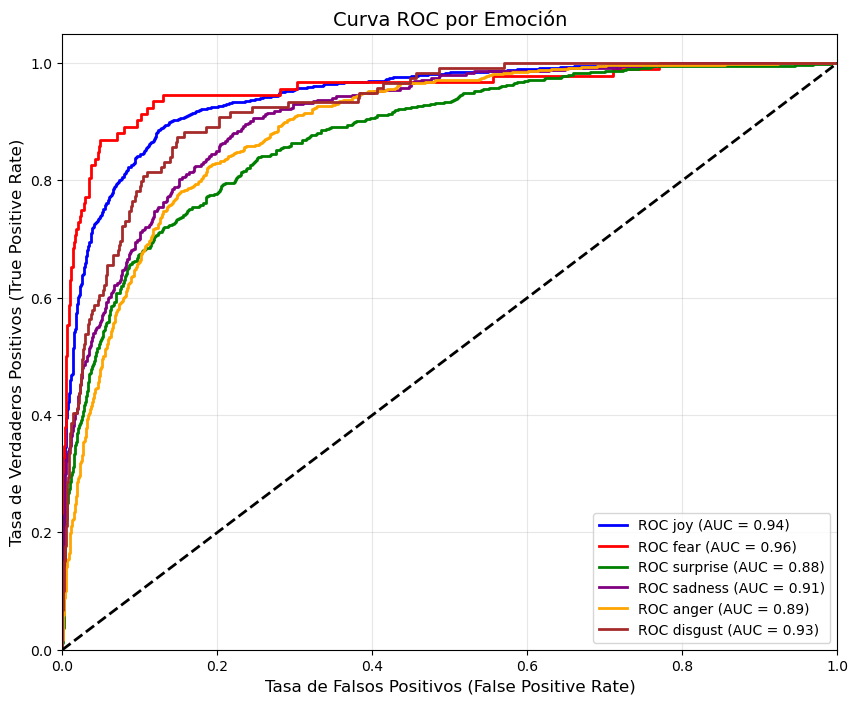

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_proba_test = model.predict_proba(X_test) 

# Diccionarios para guardar los Falsos Positivos, Verdaderos Positivos y el AUC
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = y_test.shape[1]

# 2. Calcular ROC y AUC por cada clase
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_proba_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 3. Configurar la gráfica
plt.figure(figsize=(10, 8))
colores = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink']

# 4. Graficar cada curva
for i, color in zip(range(n_classes), colores):
    nombre_clase = label_dict[mlb.classes_[i]]
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC {nombre_clase} (AUC = {roc_auc[i]:0.2f})')

# Línea diagonal de referencia (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', lw=2)

# Ajustes visuales
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (False Positive Rate)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (True Positive Rate)', fontsize=12)
plt.title('Curva ROC por Emoción', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)

# Mostrar la gráfica
plt.show()

In [48]:
import numpy as np
from sklearn.metrics import f1_score, hamming_loss, jaccard_score, classification_report

# 1. Definir función para encontrar el mejor umbral por emoción optimizando F1
def find_best_thresholds(y_true, y_proba, num_labels):
    best_thresholds = []
    for i in range(num_labels):
        # Probamos umbrales desde 0.10 hasta 0.90
        thresholds = np.arange(0.1, 0.9, 0.05)
        best_score = 0
        best_th = 0.5
        for th in thresholds:
            # Predicción binaria con el umbral actual
            y_pred_i = (y_proba[:, i] >= th).astype(int)
            # Calculamos F1-Score para esta etiqueta
            score = f1_score(y_true[:, i], y_pred_i)
            if score > best_score:
                best_score = score
                best_th = th
        best_thresholds.append(best_th)
    return best_thresholds

# 2. Predecir probabilidades en VALIDACIÓN
y_proba_val = model.predict_proba(X_val)

# 3. Calcular los umbrales óptimos
opt_thresholds = find_best_thresholds(y_val, y_proba_val, y_val.shape[1])

print("--- UMBRALES ÓPTIMOS ENCONTRADOS ---")
for i, label in enumerate([label_dict[c] for c in mlb.classes_]):
    print(f"{label}: {opt_thresholds[i]:.2f}")
print("-" * 36)

# 4. Predecir probabilidades en el set de PRUEBA (TEST)
y_proba_test = model.predict_proba(X_test)

# 5. Aplicar los umbrales personalizados a las predicciones de TEST
y_pred_tuned = np.zeros_like(y_proba_test)
for i in range(len(opt_thresholds)):
    y_pred_tuned[:, i] = (y_proba_test[:, i] >= opt_thresholds[i]).astype(int)

# 6. Calcular y mostrar las MÉTRICAS FINALES
print("\n--- MÉTRICAS GLOBALES (CON UMBRALES AJUSTADOS) ---")
print(f"Hamming Loss:    {hamming_loss(y_test, y_pred_tuned):.4f} (↓ menor es mejor)")
print(f"Jaccard (macro): {jaccard_score(y_test, y_pred_tuned, average='macro'):.4f} (↑ mayor es mejor)")

print("\n--- REPORTE DE CLASIFICACIÓN FINAL ---")
print(classification_report(
    y_test, 
    y_pred_tuned, 
    target_names=[label_dict[c] for c in mlb.classes_], 
    zero_division=0
))

--- UMBRALES ÓPTIMOS ENCONTRADOS ---
joy: 0.10
fear: 0.15
surprise: 0.65
sadness: 0.20
anger: 0.15
disgust: 0.45
------------------------------------

--- MÉTRICAS GLOBALES (CON UMBRALES AJUSTADOS) ---
Hamming Loss:    0.2817 
Jaccard (macro): 0.3211 

--- REPORTE DE CLASIFICACIÓN FINAL ---
              precision    recall  f1-score   support

         joy       0.64      0.98      0.77      1508
        fear       0.08      0.97      0.15        92
    surprise       0.63      0.67      0.65       609
     sadness       0.22      0.95      0.36       354
       anger       0.34      0.97      0.50       676
     disgust       0.18      0.88      0.30       119

   micro avg       0.38      0.92      0.54      3358
   macro avg       0.35      0.90      0.46      3358
weighted avg       0.50      0.92      0.62      3358
 samples avg       0.51      0.92      0.61      3358



In [49]:
import numpy as np
from sklearn.metrics import fbeta_score, hamming_loss, jaccard_score, classification_report

def find_balanced_thresholds(y_true, y_proba, num_labels, beta=0.5):
    best_thresholds = []
    for i in range(num_labels):
        # Empezamos a buscar desde 0.25 para evitar umbrales excesivamente bajos
        thresholds = np.arange(0.25, 0.85, 0.05)
        best_score = 0
        best_th = 0.5
        for th in thresholds:
            y_pred_i = (y_proba[:, i] >= th).astype(int)
            # fbeta_score con beta=0.5 penaliza fuertemente los falsos positivos
            score = fbeta_score(y_true[:, i], y_pred_i, beta=beta)
            if score > best_score:
                best_score = score
                best_th = th
        best_thresholds.append(best_th)
    return best_thresholds

# 1. Buscar los nuevos umbrales estrictos en VALIDACIÓN
y_proba_val = model.predict_proba(X_val)
opt_thresholds_strict = find_balanced_thresholds(y_val, y_proba_val, y_val.shape[1], beta=0.5)

print("--- NUEVOS UMBRALES (Penalizando Falsos Positivos) ---")
for i, label in enumerate([label_dict[c] for c in mlb.classes_]):
    print(f"{label}: {opt_thresholds_strict[i]:.2f}")
print("-" * 54)

# 2. Predecir en TEST con los nuevos umbrales
y_proba_test = model.predict_proba(X_test)
y_pred_balanced = np.zeros_like(y_proba_test)

for i in range(len(opt_thresholds_strict)):
    y_pred_balanced[:, i] = (y_proba_test[:, i] >= opt_thresholds_strict[i]).astype(int)

# 3. Mostrar las Métricas Finales
print("\n--- MÉTRICAS FINALES BALANCEADAS ---")
print(f"Hamming Loss:    {hamming_loss(y_test, y_pred_balanced):.4f}")
print(f"Jaccard (macro): {jaccard_score(y_test, y_pred_balanced, average='macro'):.4f}")

print("\n--- REPORTE DE CLASIFICACIÓN FINAL ---")
print(classification_report(
    y_test, 
    y_pred_balanced, 
    target_names=[label_dict[c] for c in mlb.classes_], 
    zero_division=0
))

--- NUEVOS UMBRALES (Penalizando Falsos Positivos) ---
joy: 0.25
fear: 0.40
surprise: 0.80
sadness: 0.60
anger: 0.25
disgust: 0.60
------------------------------------------------------

--- MÉTRICAS FINALES BALANCEADAS ---
Hamming Loss:    0.1640
Jaccard (macro): 0.3886

--- REPORTE DE CLASIFICACIÓN FINAL ---
              precision    recall  f1-score   support

         joy       0.77      0.94      0.85      1508
        fear       0.18      0.95      0.30        92
    surprise       0.76      0.48      0.59       609
     sadness       0.44      0.75      0.55       354
       anger       0.40      0.95      0.56       676
     disgust       0.24      0.78      0.37       119

   micro avg       0.53      0.84      0.65      3358
   macro avg       0.46      0.81      0.54      3358
weighted avg       0.62      0.84      0.68      3358
 samples avg       0.64      0.85      0.69      3358



Calibrando el modelo con el set de validación...
 Modelo calibrado guardado exitosamente en: 'modelo_emociones_calibrado.pkl'

--- UMBRALES ÓPTIMOS (PROBABILIDADES CALIBRADAS) ---
joy: 0.50
fear: 0.30
surprise: 0.25
sadness: 0.25
anger: 0.25
disgust: 0.50
----------------------------------------------------
 Imagen de la curva ROC guardada como: 'roc_curve_calibrated.png'


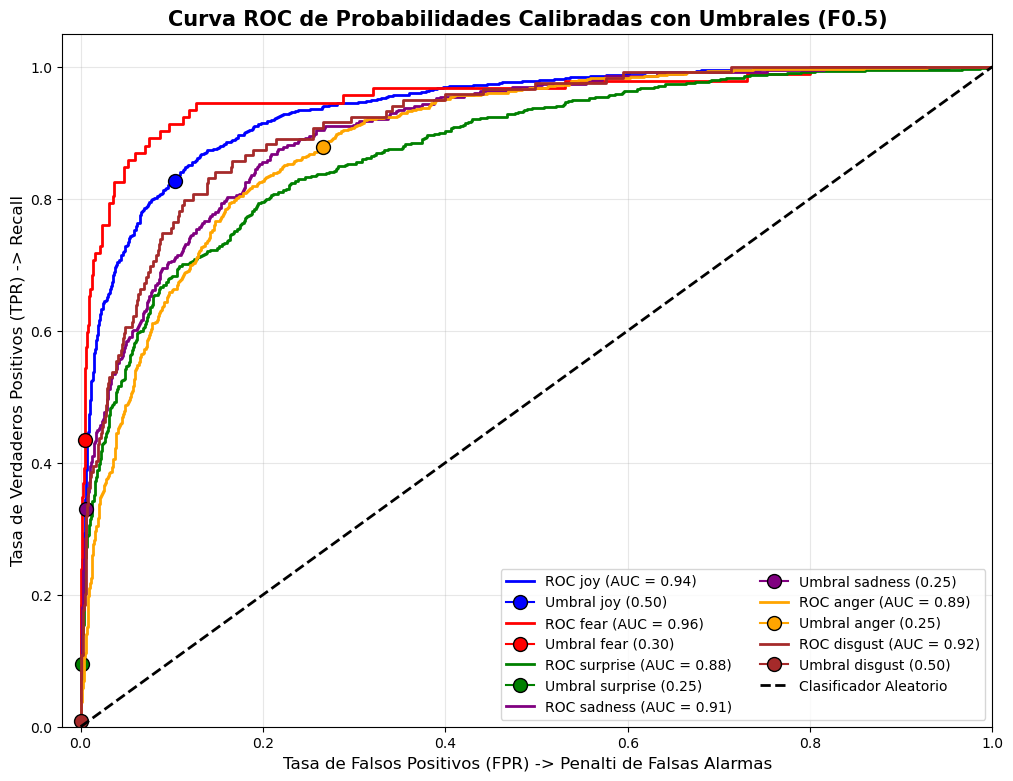

In [54]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import fbeta_score, roc_curve, auc

# ==========================================
# 2. BUSCAR NUEVOS UMBRALES (F-Beta 0.5)
# ==========================================
def find_balanced_thresholds(y_true, y_proba, num_labels, beta=0.5):
    best_thresholds = []
    for i in range(num_labels):
        thresholds = np.arange(0.25, 0.85, 0.05)
        best_score = 0
        best_th = 0.5
        for th in thresholds:
            y_pred_i = (y_proba[:, i] >= th).astype(int)
            score = fbeta_score(y_true[:, i], y_pred_i, beta=beta)
            if score > best_score:
                best_score = score
                best_th = th
        best_thresholds.append(best_th)
    return best_thresholds

# Predecir probabilidades calibradas en validación y test
y_proba_val_cal = calibrated_model.predict_proba(X_val)
y_proba_test_cal = calibrated_model.predict_proba(X_test)

# Encontrar umbrales óptimos penalizando falsos positivos
opt_thresholds = find_balanced_thresholds(y_val, y_proba_val_cal, y_val.shape[1], beta=0.5)

print("--- UMBRALES ÓPTIMOS (PROBABILIDADES CALIBRADAS) ---")
for i, label in enumerate([label_dict[c] for c in mlb.classes_]):
    print(f"{label}: {opt_thresholds[i]:.2f}")
print("-" * 52)

# ==========================================
# 3. GRAFICAR CURVA ROC Y MARCAR UMBRALES
# ==========================================
plt.figure(figsize=(12, 9))
colores = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink']
n_classes = y_test.shape[1]

for i, color in zip(range(n_classes), colores):
    nombre_clase = label_dict[mlb.classes_[i]]
    
    # Calcular Curva ROC y AUC para la clase i
    fpr_i, tpr_i, roc_thresholds = roc_curve(y_test[:, i], y_proba_test_cal[:, i])
    roc_auc_i = auc(fpr_i, tpr_i)
    
    # Trazar la línea de la curva
    plt.plot(fpr_i, tpr_i, color=color, lw=2, 
             label=f'ROC {nombre_clase} (AUC = {roc_auc_i:0.2f})')
    
    # Encontrar el punto exacto en la curva que corresponde a tu umbral penalizado
    # Buscamos el índice del umbral de la curva ROC más cercano a nuestro umbral óptimo
    idx_umbral = np.argmin(np.abs(roc_thresholds - opt_thresholds[i]))
    
    # Dibujar un punto grande donde cae el umbral elegido
    plt.plot(fpr_i[idx_umbral], tpr_i[idx_umbral], marker='o', color=color, 
             markersize=10, markeredgecolor='black', 
             label=f'Umbral {nombre_clase} ({opt_thresholds[i]:.2f})')

# Línea diagonal (aleatoria)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Clasificador Aleatorio')

# Formato final de la gráfica
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR) -> Penalti de Falsas Alarmas', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR) -> Recall', fontsize=12)
plt.title('Curva ROC de Probabilidades Calibradas con Umbrales (F0.5)', fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=10, ncol=2)
plt.grid(alpha=0.3)
nombre_imagen = 'roc_curve_calibrated.png'
plt.savefig(nombre_imagen, dpi=300, bbox_inches='tight')
print(f" Imagen de la curva ROC guardada como: '{nombre_imagen}'")

plt.show()

 Todo el pipeline fue guardado exitosamente como: 'lreg_en.pkl'
